In [1]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [2]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [3]:
from miRBench.dataset import list_datasets, get_dataset_df

In [4]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [5]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

In [6]:
hejret_train

,gene,noncodingRNA,noncodingRNA_name,noncodingRNA_fam,feature,label,chr,start,end,strand,gene_cluster_ID
0,CCCAGGGTGTTTCATGCTGAGGTAGTAGGATGAATAAAGGCAAATA...,CTATACAATCTACTGTCTTTC,hsa-let-7a-3p,let-7,NaN,1,13,103634174,103634223,-,355
1,CAACTCTATACAACACACCTACTATCTCTTGATGCCCTATTGACAG...,TGAGGTAGTAGGTTGTGTGGTT,hsa-let-7a-5p,let-7,exon,1,10,102362496,102362545,+,1611
2,TAGAGGATCCTAGACCAGCATGCCAGTGTGCCAAGGCCACAGGGAA...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,65500706,65500755,+,1457
3,CATCCCCCTGACGGCCGAGAAGCTGTGCATCTACACCGACAACTCC...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,69643180,69643229,+,97
4,CAACATGAAACAGTTCATCCGCTACCTCATCTCGTCCAACGTCGGG...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,12,110342392,110342441,+,3303
...,...,...,...,...,...,...,...,...,...,...,...
8188,TGATAGTTCAGCTTGAATGTCTCTTAGAGGGTGGGCTTTTGTTGAT...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,exon,0,11,65502560,65502609,+,2508
8189,GTGGGACTGCTCTGTCCCCTGCCCCTACTGCAGAGATAGCACTGCC...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,three_prime_utr,0,17,49053543,49053592,+,239
8190,CCATTTCTTTGGATTTGCCTCTCCTGGACATTTCATATAGATGAAA...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,intron,0,15,101365823,101365872,-,423
8191,CATCACATGCAGGTGGGCCTGGGCTCCTTGGGAGGAAGTATGGTGG...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,"intron,exon",0,17,1651376,1651425,-,65


# Optimization

### Simple model on miRNA alignments:

In [7]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [8]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [9]:
mirlist[0]

Seq('CTATACAATCTACTGTCTTTC')

In [10]:
genelist[0]

Seq('TGCATATTTGCCTTTATTCATCCTACTACCTCAGCATGAAACACCCTGGG')

In [11]:
print(next(aligner.align(mirlist[1], genelist[1])))

target            1 GAGGTAGTAGGT-TG-TGT---G-GTT 22
                  0 |||.||||||||-||-|||---|-||| 27
query            22 GAGATAGTAGGTGTGTTGTATAGAGTT 49



In [12]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

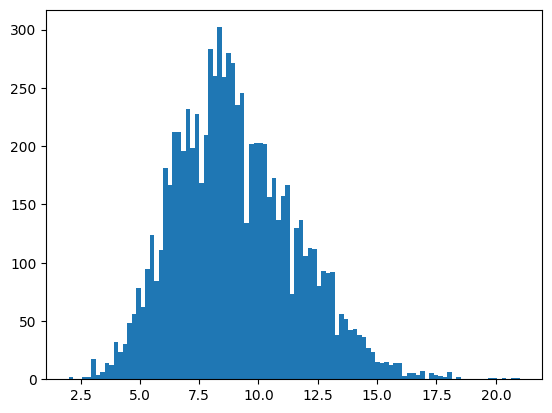

In [13]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [14]:
true_alpha = -9

In [15]:
logit_scores = logit_partial_scores(scores, true_alpha)

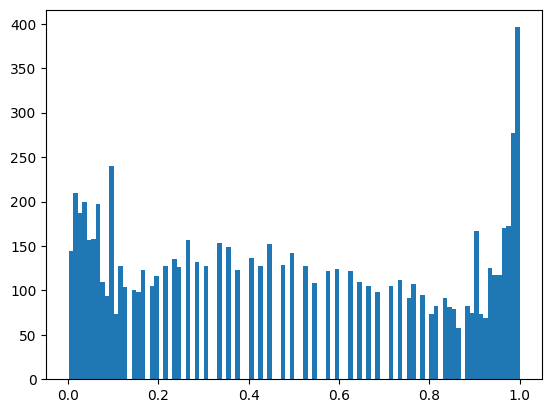

In [16]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [17]:
rd.rand(10)

array([0.50333182, 0.25538826, 0.80877594, 0.86964893, 0.4466972 ,
       0.26067459, 0.32408339, 0.54407701, 0.68415497, 0.9113286 ])

In [18]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
labels

array([False,  True, False, ..., False,  True,  True], shape=(8193,))

In [19]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -10002.78024009512
True LogL: -3371.2802400951223


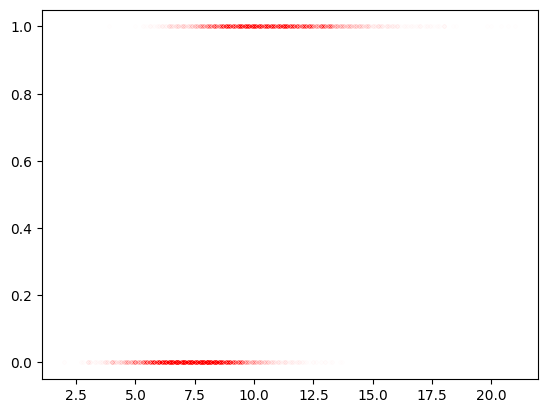

In [20]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

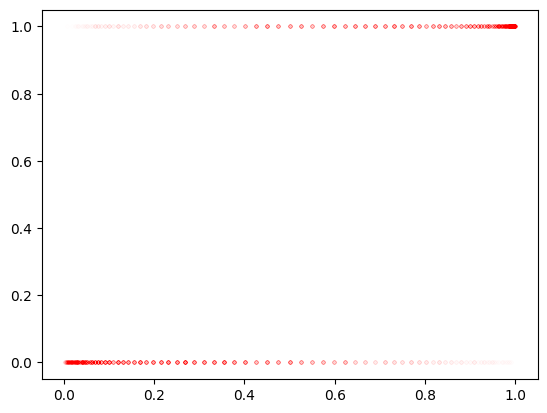

In [21]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [22]:
const_step = create_constant_step(0.00005)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [23]:
NITER = 5 # original 50

In [24]:
# Task 1: Run estimalign across different step sizes and plot:
# (1) logL trajectories to see convergence behavior
# (2) scatter of convergence speed vs final parameter error to find the best step size

step_sizes = [0.000005, 0.00001, 0.00005, 0.0001, 0.0005]
task1_results = {}

for ss in step_sizes:
    step = create_constant_step(ss)
    p = estimalign(mirlist, genelist, labels,
                   stepfunction=step, aligner_mode='local',
                   substitution_mode='simple', verbose=False,
                   max_iter=NITER, stochastic_factor=None, num_threads=16)
    task1_results[ss] = p

# Trajectory plot
plt.figure()
for ss, p in task1_results.items():
    plt.plot(p['loglik_trajectory'], label=f'step={ss}')
plt.axhline(true_logL, color='k', linestyle='--', label='True LogL')
plt.xlabel('Iteration'); plt.ylabel('LogL')
plt.title('LogL Trajectories by Step Size')
plt.legend(); plt.tight_layout(); plt.show()

# Scatter: convergence speed vs final parameter error
def param_error(p):
    return (abs(p['match_score'] - true_match) +
            abs(p['mismatch_score'] - true_mismatch) +
            abs(p['open_gap_score'] - true_gapopen) +
            abs(p['extend_gap_score'] - true_gapext) +
            abs(p['alpha'] - true_alpha))

# convergence = first iteration where subgradient L2 norm drops below threshold
threshold = 0.01
conv_iters = []
errors = []
for ss, p in task1_results.items():
    grads = p['subgradient_l2_trajectory']
    conv = next((i for i, g in enumerate(grads) if g < threshold), NITER)
    conv_iters.append(conv)
    errors.append(param_error(p))

plt.figure()
for i, ss in enumerate(step_sizes):
    plt.scatter(conv_iters[i], errors[i], label=f'step={ss}', s=100)
plt.xlabel('Iterations to Converge')
plt.ylabel('Total Parameter Error')
plt.title('Convergence Speed vs Parameter Error')
plt.legend(); plt.tight_layout(); plt.show()

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


TypeError: only 0-dimensional arrays can be converted to Python scalars

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

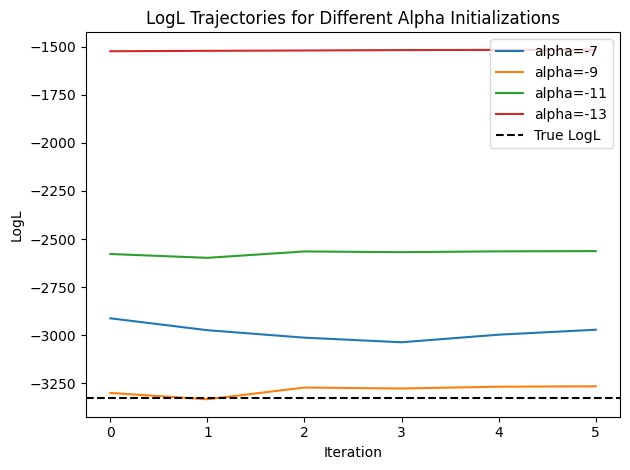

In [ ]:
# Task 2: Run estimalign with different alpha values and overlay their logL trajectories to see how starting conditions affect optimization

alphas = [-7, -9, -11, -13]
best_step = 0.000005  # use the best step size you find in task 1 

plt.figure()
for alpha in alphas:
    ls = logit_partial_scores(scores, alpha)
    lbs = rd.rand(len(mirlist)) <= ls
    p = estimalign(mirlist, genelist, lbs,
                   stepfunction=create_constant_step(best_step),
                   aligner_mode='local', substitution_mode='simple',
                   verbose=False, max_iter=NITER,
                   stochastic_factor=None, num_threads=16)
    plt.plot(p['loglik_trajectory'], label=f'alpha={alpha}')

plt.axhline(true_logL, color='k', linestyle='--', label='True LogL')
plt.xlabel('Iteration'); plt.ylabel('LogL')
plt.title('LogL Trajectories for Different Alpha Initializations')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    verbose=True, max_iter=NITER,
                    stochastic_factor=None,
                    num_threads = 16)

Alphabet:
TAGC


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Initial parameters:
{'alpha': np.float64(-8.140048569804847), 'match_score': np.float64(0.9313242114827851), 'mismatch_score': np.float64(-0.8069277168359406), 'open_gap_score': np.float64(-1.1964991240556657), 'extend_gap_score': np.float64(-0.09426022117450192)}
Start of iteration 0
Current alpha: -8.140048569804847
Current logL: -3355.1608774391225
Updated alpha: -8.286403368320368
Updated logL: -3343.199175708037
New subgradient:
{'Substitutions': Array([[160.81357664, -23.47623648,  -3.51275113, -26.81544221],
       [  5.71796641,   0.88933917, -14.73908692,   0.51255974],
       [-13.28210718, -37.33707439,  47.63551327, -11.91899157],
       [ -0.68676735, -12.26043138, -17.11791909,  42.07702907]],
         alphabet='TAGC'), 'Gap opens': np.float64(195.5319791530951), 'Gap extends': np.float64(270.1035920355006)}
Stepsize: 5e-05
Gap open step: 0.009776598957654755
Gap extend step: 0.01350517960177503
Match step: 0.01257077290737787
Mismatch step: -0.007745814077635061
New para

In [ ]:
print(params['final_loglik'])

-3342.2996327857895


In [ ]:
print(params['final_loglik'])

-3342.2996327857895


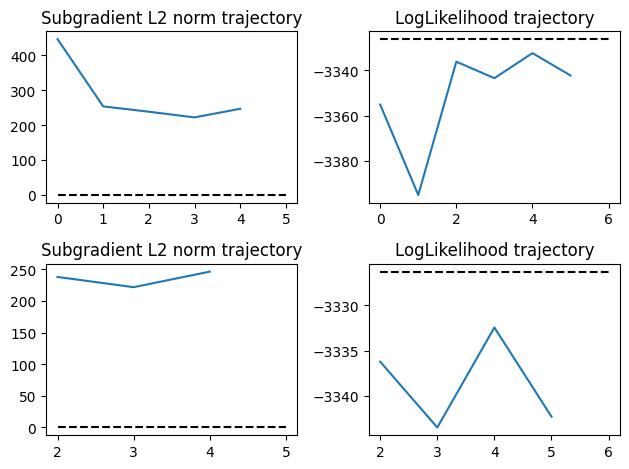

In [ ]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

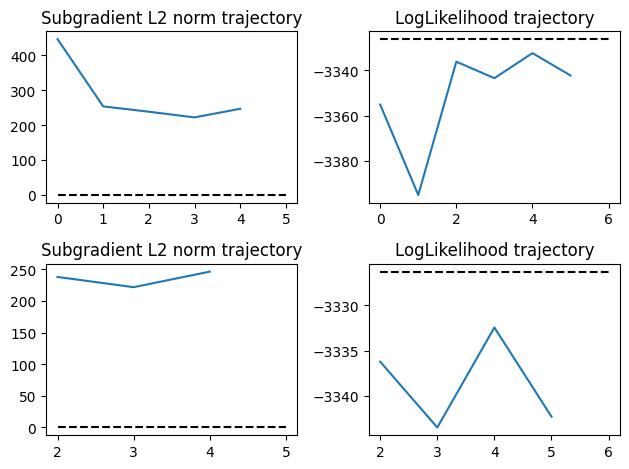

In [ ]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [ ]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 0.9617223562932656
-1 -0.8375566610187599
-1.2 -1.168220610724537
-0.1 -0.09040388387999129
-9 -8.686143713388764


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

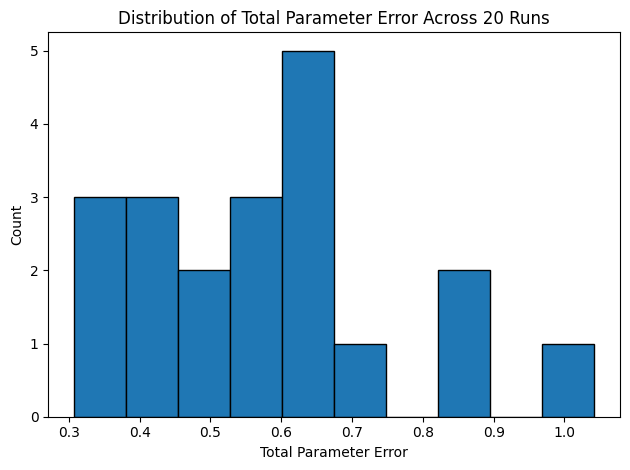

/tmp/ipykernel_20692/3223624895.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(per_param_errors.values(), labels=param_names, showfliers=True)


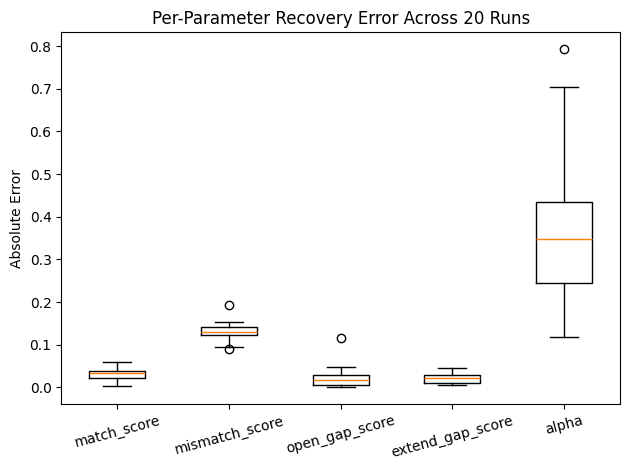

In [ ]:
# Task 3: Run estimalign 20 times with different random seeds and plot:
# 1) a histogram of total parameter error per run
# 2) per-parameter boxplots to show which parameters are reliably recovered

N_SEEDS = 20
best_step = 0.000005 # again using best step size from task 1
param_names = ['match_score', 'mismatch_score', 'open_gap_score', 'extend_gap_score', 'alpha']
true_values = [true_match, true_mismatch, true_gapopen, true_gapext, true_alpha]

per_param_errors = {name: [] for name in param_names}
total_errors = []

for seed in range(N_SEEDS):
    rd.seed(seed)
    ls = logit_partial_scores(scores, true_alpha)
    lbs = rd.rand(len(mirlist)) <= ls
    p = estimalign(mirlist, genelist, lbs,
                   stepfunction=create_constant_step(best_step),
                   aligner_mode='local', substitution_mode='simple',
                   verbose=False, max_iter=NITER,
                   stochastic_factor=None, num_threads=16)
    
    total = 0
    for name, true_val in zip(param_names, true_values):
        err = abs(p[name] - true_val)
        per_param_errors[name].append(err)
        total += err
    total_errors.append(total)

# Histogram of total error per run
plt.figure()
plt.hist(total_errors, bins=10, edgecolor='black')
plt.xlabel('Total Parameter Error')
plt.ylabel('Count')
plt.title('Distribution of Total Parameter Error Across 20 Runs')
plt.tight_layout(); plt.show()

# Per-parameter boxplots
plt.figure()
plt.boxplot(per_param_errors.values(), labels=param_names, showfliers=True)
plt.ylabel('Absolute Error')
plt.title('Per-Parameter Recovery Error Across 20 Runs')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

### General matrix, affine gap penalty

In [ ]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

In [ ]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [ ]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

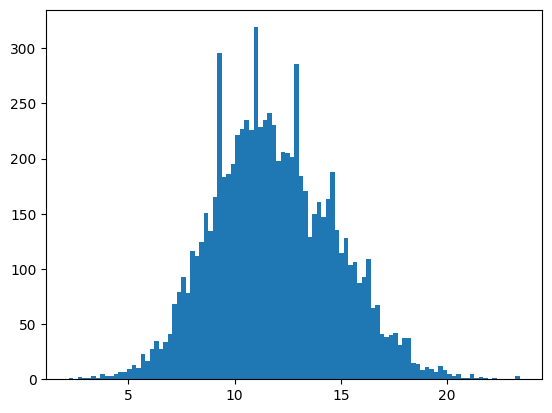

In [ ]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [ ]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

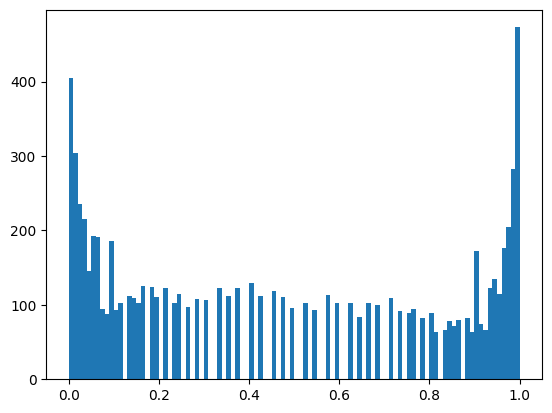

In [ ]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [ ]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11654.43085041492
True LogL: -3036.230850414926


In [ ]:
const_step = create_constant_step(0.00005)
# powerstep = create_powerstep(0.00005, power=0.5, burnin=0)
powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [ ]:
NITER = 200

In [ ]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    stochastic_factor=0.01,
                    verbose=True, max_iter=NITER,
                    num_threads = 24)

Alphabet:
TAGC
Initial parameters:
{'alpha': np.float64(-9.248898888924476), 'substitution_matrix': Array([[ 0.86333505, -0.82528501, -0.84850172, -0.33003205],
       [-0.81244892,  0.83025893, -0.81096694, -0.42662745],
       [-0.69817859, -0.55695801,  1.10686252, -0.74045004],
       [-0.3581916 , -0.73818416, -0.76683744,  1.02311208]],
         alphabet='TAGC'), 'open_gap_score': np.float64(-1.1620293274985511), 'extend_gap_score': np.float64(-0.08836125850366112)}
Start of iteration 0
Current alpha: -9.248898888924476
Current logL: -3111.652134973054
Updated alpha: -9.541800204353006
Updated logL: -3066.43401658418
New subgradient:
{'Substitutions': Array([[131.97065349, -19.93491638,   7.12934367,   9.56153684],
       [ -9.42519647, 102.52186393,   4.04677909,  16.41887516],
       [ -7.75922685,  35.07362221, 147.73829025, -22.26379891],
       [ 13.9557812 ,  19.86935839,  -6.57548114,  68.36646075]],
         alphabet='TAGC'), 'Gap opens': np.float64(163.54472693733751), '

In [ ]:
print(params['final_loglik'])

-3027.1923145240653


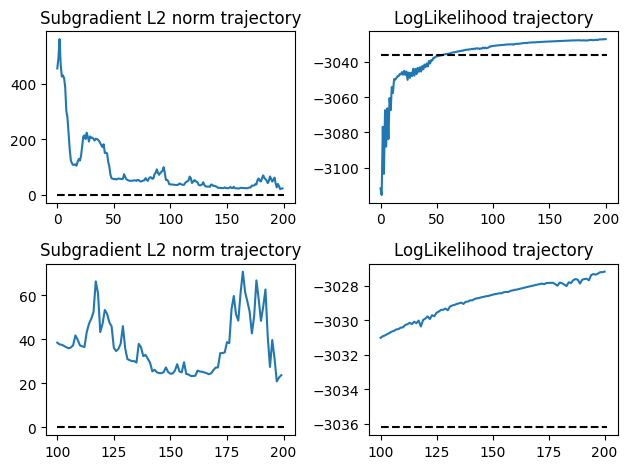

In [ ]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [ ]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))
print(np.mean(np.abs(np.array(true_subs_vector)- np.array(param_subs_vector))))

-1.2 -1.2005192367688053
-0.1 -0.09395746028620854
-12 -11.601268166515428
A A 1.0 0.9524239857437646
A C -0.3 -0.29474025019034306
A T -1.0 -0.8970066444417296
A G -0.8 -0.8012380513881414
C A -0.6 -0.6413646082077518
C C 1.2 1.1555940819120964
C T -0.3 -0.312392040868693
C G -1.0 -0.8480663554421467
T A -1.2 -1.0231584136004288
T C -0.4 -0.28317770506732504
T T 1.0 0.9975105329809105
T G -0.8 -0.8016133157900743
G A -0.4 -0.394943881576396
G C -1.4 -0.8608147525333919
G T -0.9 -0.7854775310172313
G G 1.3 1.2589487371240602
[[1.         0.98975579]
 [0.98975579 1.        ]]
0.08779657153905226


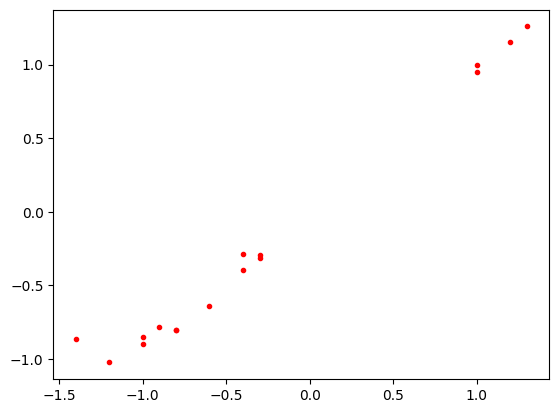

In [ ]:
plt.figure()
plt.plot(true_subs_vector, param_subs_vector, 'r.')

In [ ]:
from src.optimization import get_initial_estimate

In [ ]:
get_initial_estimate(params['alignments'], labels, substitution_mode='general', gap_mode='affine',
                     alphabet=true_substitution.alphabet)

{'alpha': np.float64(-11.713884395772133),
 'substitution_matrix': Array([[ 0.96719463, -0.28620912, -0.9437976 , -0.82335916],
        [-0.61946887,  1.17013331, -0.31764215, -0.93333448],
        [-1.14749349, -0.28979949,  1.01177002, -0.78432492],
        [-0.39613487, -0.93207474, -0.81821397,  1.2749107 ]],
          alphabet='ACTG'),
 'open_gap_score': np.float64(-1.222531825266427),
 'extend_gap_score': np.float64(-0.09475888225094037)}

In [ ]:
true_substitution

Array([[ 1. , -0.3, -1. , -0.8],
       [-0.6,  1.2, -0.3, -1. ],
       [-1.2, -0.4,  1. , -0.8],
       [-0.4, -1.4, -0.9,  1.3]],
         alphabet='ACTG')

In [ ]:
estim_substitution = true_substitution.copy()
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        estim_substitution[char1, char2] = params['substitution_matrix'][char1, char2]

In [ ]:
estim_substitution

Array([[ 0.95242399, -0.29474025, -0.89700664, -0.80123805],
       [-0.64136461,  1.15559408, -0.31239204, -0.84806636],
       [-1.02315841, -0.28317771,  0.99751053, -0.80161332],
       [-0.39494388, -0.86081475, -0.78547753,  1.25894874]],
         alphabet='ACTG')

# Proteins

### Simulated alignments

In [ ]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [ ]:
coupling = 2**blosum62/(len(blosum62.alphabet)**2)
coupling /= np.sum(coupling)

In [ ]:
aa_pairs = [(char1, char2) for char1 in blosum62.alphabet for char2 in blosum62.alphabet]
prob_vect = [coupling[aapair] for aapair in aa_pairs]

In [ ]:
for aa, prob in zip(aa_pairs, prob_vect):
    print(aa, prob)

('A', 'A') 0.003933257536182897
('A', 'R') 0.00012291429800571552
('A', 'N') 6.145714900285776e-05
('A', 'D') 6.145714900285776e-05
('A', 'C') 0.00024582859601143104
('A', 'Q') 0.00012291429800571552
('A', 'E') 0.00012291429800571552
('A', 'G') 0.00024582859601143104
('A', 'H') 6.145714900285776e-05
('A', 'I') 0.00012291429800571552
('A', 'L') 0.00012291429800571552
('A', 'K') 0.00012291429800571552
('A', 'M') 0.00012291429800571552
('A', 'F') 6.145714900285776e-05
('A', 'P') 0.00012291429800571552
('A', 'S') 0.0004916571920228621
('A', 'T') 0.00024582859601143104
('A', 'W') 3.072857450142888e-05
('A', 'Y') 6.145714900285776e-05
('A', 'V') 0.00024582859601143104
('A', 'B') 6.145714900285776e-05
('A', 'Z') 0.00012291429800571552
('A', 'X') 0.00024582859601143104
('A', '*') 1.536428725071444e-05
('R', 'A') 0.00012291429800571552
('R', 'R') 0.007866515072365793
('R', 'N') 0.00024582859601143104
('R', 'D') 6.145714900285776e-05
('R', 'C') 3.072857450142888e-05
('R', 'Q') 0.0004916571920228

In [ ]:
SETSIZE = 5000

In [ ]:
Alist = []
Blist = []
for _ in range(SETSIZE):
    pairs = rd.choice(len(aa_pairs), p=prob_vect, replace=True, size=250)
    pairs = [aa_pairs[i] for i in pairs]
    aseq = ''.join(x[0] for x in pairs)
    bseq = ''.join(x[1] for x in pairs)
    Alist.append(aseq)
    Blist.append(bseq)

In [ ]:
Blist

['WVWYCEKWWWWWCCCGWHYCWWWEWWWWWWCWWQWCWQWWWWCWWHWWTWYGWCQKCCWYWWWYEWWWWGWWWNGBWWWWWCYWWNWYWCWEWWCBCWNWHWWYWWWFWWSZGPWWAHRPVWCZWYHWCWCCWWWDHWNGCWCWEWCCWWWHCWWWWQWCWWHWWWWWWHWWTWNWYNPCSNQWWWWWICWCWWWNKHCWSCWMWDWCRDWFBWCCWCWMAWWWPWFWWWCWPWCNWWCWCWWWBWWCCW',
 'VWWCWHWHWFWCWFWIWHWRFWWWWWWHWWCWCWDHWWCWWHWDWWCWYCWWESCWWWWWCWPWPCWCHYCFYNCXWWWHCHWNWWZWRWCDXRNWWDWCWWWWPWWHMCWYWKPWCWCZDWHFCWKPWCWDZWWCWHCWYWWWWWBHTHCCWHNHHWWCCWKNYWCWZCWWWWWNWDWCDYWWCWCCWWWCWWWWWZHYWWAXYWCFWCWWHWHCCFWPWHYWPWEBWWWYCCWWWWWWPPWWHWDWPW',
 'WTWWWZWWRSWHWCWWGWWHCHWWCWCFYWWTWWRWWRWRZRCQWWDWWWHWBDPHAWIWHIHWTMWWWYWFGGDWWWCKFWEEGWWWWWWWPWSWDFCWWHWPXMWWCCWWWWWCBZWWYWYPCWWWWWCWWMHWWWWWCCFBECWWHFWWEWLCWWAQWCWPWWWNTDWLWQZWWQCWIMWYWCWWCWWWKWWWDHYWDWKWCHDWHCQDWWCVPAYAQWWWWWWYEYHWHWICWWVFHQBDCWCNWW',
 'WWWHWWWWENWFWGWZFPCHWBWYWWCGWWWLWDYWCWWWWWHHPWCWWWCWWWCWFWCHWWWFWWNDYWWWWHWWWCWHWMWWWCWWRWWWMWYWWWWNWYWPHEQWXWWPCWCWWYCWWNWWWHWWYFHWNWWHEWCCWWDWYCQWWHCWNWQVWWHGHHWWWCHDWACAEZWHMWYWWWWPPCWFWGWWWMWWCCHQWWNWPYCWWWWRWLWWPGQCWWHWWWWHWWWWY

### Symmetric matrix on protein alignments:

In [ ]:
positive_id_tuples = []
close_negative_id_tuples = []
with open('./Proteomes/human_to_chicken_upto1000aa.blast') as h:
    for l in h:
        l = l.split('\t')
        evalue = float(l[-2])
        if evalue == 0:
            positive_id_tuples.append([l[0], l[1]])
        elif evalue > 0.0001:
            close_negative_id_tuples.append([l[0], l[1]])

FileNotFoundError: [Errno 2] No such file or directory: './Proteomes/human_to_chicken_upto1000aa.blast'

In [ ]:
human_proteome = list(SeqIO.parse('Proteomes/GCF_000001405.40/up_to_1000.faa', 'fasta'))
chick_proteome = list(SeqIO.parse('Proteomes/GCF_016699485.2/up_to_1000.faa', 'fasta'))

In [ ]:
alphabet = 'ACDEFGHIKLMNPQRSTVWY'

In [ ]:
human_proteome = [seq for seq in human_proteome if set(str(seq.seq)).issubset(set(alphabet))]
chick_proteome = [seq for seq in chick_proteome if set(str(seq.seq)).issubset(set(alphabet))]

In [ ]:
human_prot_ids = [seq.id for seq in human_proteome]
chick_prot_ids = [seq.id for seq in chick_proteome]

In [ ]:
human_prot_ids_set = set(human_prot_ids)
chick_prot_ids_set = set(chick_prot_ids)

In [ ]:
positive_id_tuples = [t for t in positive_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]
# close_negative_id_tuples = [t for t in close_negative_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]

In [ ]:
SETSIZE = 5000

In [ ]:
# pos_set = rd.choice(len(positive_id_tuples), SETSIZE//2, replace=False)
# neg_set = rd.choice(len(close_negative_id_tuples), SETSIZE//2, replace=False)
# prot_dset = [positive_id_tuples[i] for i in pos_set] + [close_negative_id_tuples[i] for i in neg_set]
pos_set = rd.choice(len(positive_id_tuples), SETSIZE, replace=False)
prot_dset = [positive_id_tuples[i] for i in pos_set]

In [ ]:
human_list = [human_proteome[human_prot_ids.index(hpid)] for hpid, cpid in prot_dset]
chick_list = [chick_proteome[chick_prot_ids.index(cpid)] for hpid, cpid in prot_dset]

In [ ]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [ ]:
blosum62 /= np.sqrt(np.sum(blosum62**2))

In [ ]:
aligner = PairwiseAligner()
aligner.mode = 'global'
aligner.substitution_matrix=blosum62
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.1

Example scores of alignments to visualize gap open and extend penalties for global alignment:

In [ ]:
test_aln = aligner.align('ATA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1, test_aln.score)
test_aln = aligner.align('ATTA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1 - 0.1, test_aln.score)

In [ ]:
scores = np.array([aligner.score(a, b) for a, b in zip(human_list, chick_list)])

In [ ]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [ ]:
print(next(aligner.align(human_list[0], chick_list[0])))

In [ ]:
logit_scores = logit_partial_scores(scores, -20)

In [ ]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

Expectation check:

In [ ]:
logL_distribution = []
for _ in range(5000):
    labels = rd.rand(len(human_list))
    labels = labels <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    logL_distribution.append(true_logL)

In [ ]:
plt.figure()
plt.hist(logL_distribution, bins=100)
plt.show()

In [ ]:
EL = 0 
VL = 0
for ls in logit_scores:
    if 1e-24 < ls < 1-1e-24:
        EL += ls*np.log(ls) + (1-ls)*np.log(1-ls)
        VL += ls*(1-ls)*(np.log(ls)**2 + np.log(1-ls)**2) # Incorrect
SDL = np.sqrt(VL)

In [ ]:
print('Expected LogL:', EL)
print('Average LogL:', np.mean(logL_distribution))
print('STD LogL:', SDL)
print('Sample STD:', np.std(logL_distribution))

Fitting:

In [ ]:
labels = rd.rand(len(human_list))
labels = labels <= logit_scores

In [ ]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [ ]:
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

In [ ]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.5)

In [ ]:
const_step = create_constant_step(0.00005)
powerstep = create_powerstep(0.000005, power=0.5, burnin=0) # step 0.00005 good for SETSIZE==1000
# powerstep = create_powerstep(0.0000001, power=-0.5, burnin=0)

In [ ]:
NITER = 50

In [ ]:
set('WEIMFASVCGKLTHDPRNQY') == set(alphabet) 

In [ ]:
params = estimalign(human_list, chick_list, labels, 
                    stepfunction=powerstep,
                    aligner_mode='global',
                    substitution_mode='general',
                    gap_mode='affine',
                    baseline_aligner=aligner,
                    stochastic_factor=0.0001,
                    verbose=True, max_iter=NITER,
                    num_threads = 16)

In [ ]:
print(params['final_loglik'])

In [ ]:
print(max(params['loglik_trajectory']))

In [ ]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [ ]:
print(params['open_gap_score'], aligner.open_gap_score)
print(params['extend_gap_score'], aligner.extend_gap_score)

In [ ]:
params['alpha']

In [ ]:
blosum_vs_mine = []
for char1 in params['substitution_matrix'].alphabet:
    for char2 in params['substitution_matrix'].alphabet:
        if char1 != 'N' and char2 != 'N':
            blosum_vs_mine.append([char1, char2,blosum62[char1, char2], params['substitution_matrix'][char1, char2]])

In [ ]:
print('Blosum, Mine')
for i in rd.choice(len(blosum_vs_mine), 10, replace=False):
    print(blosum_vs_mine[i])

In [ ]:
np.corrcoef([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine])

In [ ]:
plt.figure()
plt.plot([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine], 'r.')

In [ ]:
plt.figure()
plt.plot(sorted([x[2] for x in blosum_vs_mine]), sorted([x[3] for x in blosum_vs_mine]), 'r.')